# **Project Title:** Amazon Sales Performance Analysis

# Project Overview:
- Analyze Amazon sales data to understand overall sales performance, product performance, customer orders, geographic trends, fulfilment performance, and B2B vs B2C sales using an interactive Power BI dashboard.

# Business Objective:
- The objective of this project is to transform raw Amazon sales data into meaningful insights by tracking key KPIs, identifying high-performing products and categories, analyzing sales trends, understanding geographic performance, and evaluating fulfilment and customer-type sales distribution.

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os


# Load Dataset

In [3]:
df = pd.read_csv(r'D://Portfolio//project 1/Artifacts/Datasets/Amazon Sale Report.csv', encoding='latin1')

In [4]:
# dataset shape

df.shape

(128975, 24)

# Dataset Understanding

In [5]:
# check head
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [6]:
# check metadata
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [7]:
# check missing values

df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [8]:
# check duplicates

df.duplicated().sum()

np.int64(0)

In [9]:
# inspect these two columns
df[['index', 'Unnamed: 22']].sample(10)

,index,Unnamed: 22
97906,97906,False
39086,39086,NaN
42306,42306,NaN
17988,17988,NaN
23974,23974,NaN
72331,72331,False
117346,117346,False
9061,9061,NaN
42686,42686,NaN
3186,3186,NaN


In [10]:
# check statistical summary

df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [11]:
# statistical summary for objects features

df.describe(include='object').T

,count,unique,top,freq
Order ID,128975,120378,403-4984515-8861958,12
Date,128975,91,5/3/2022,2085
Status,128975,13,Shipped,77804
Fulfilment,128975,2,Amazon,89698
Sales Channel,128975,2,Amazon.in,128851
ship-service-level,128975,2,Expedited,88615
Style,128975,1377,JNE3797,4224
SKU,128975,7195,JNE3797-KR-L,773
Category,128975,9,Set,50284
Size,128975,11,M,22711


### observations:
- Dataset contains 128,975 records and 24 columns.
- No completely duplicate records were found.
- Date is stored as an object and needs conversion to datetime.
- Missing values are present in columns such as Amount, currency, Courier Status, and shipping details.
- promotion-ids and fulfilled-by have a large number of missing values and need business-context investigation before treatment.
- index appears to be an unnecessary row identifier.
- Unnamed: 22 appears to be an unclear/unnecessary column and can likely be removed after validation.
- `Qty` ranges from **0 to 15**, with a median quantity of **1**, indicating that most records represent small-quantity orders.
- `Amount` ranges from **₹0 to ₹5,584**, with a median of **₹605**. Missing values are also present and require further investigation.
- The dataset contains **9 product categories**, with `Set` being the most frequently occurring category.
- There are **13 different order statuses**, with `Shipped` being the most frequent status.
- The majority of orders are fulfilled by **Amazon**, based on the `Fulfilment` column.
- `Amazon.in` is the dominant sales channel in the dataset.
- `INR` is the only recorded currency among non-missing currency values.
- The dataset contains orders from **8,955 cities and 69 states**, providing good potential for geographic sales analysis.
- `BENGALURU` is the most frequently occurring city, while `MAHARASHTRA` is the most frequently occurring state.
- The dataset contains useful information for analyzing sales, orders, products, fulfilment, shipping locations, and B2B/B2C transactions.

# Data Cleaning

In [12]:
# remove unnecessary columns

df.drop(columns=['index', 'Unnamed: 22'], inplace=True)
df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,405-8078784-5731545,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship
1,171-9198151-1101146,4/30/2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,404-0687676-7273146,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN
3,403-9615377-8133951,4/30/2022,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship
4,407-1069790-7240320,4/30/2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN


In [13]:
# dataset shape

df.shape

(128975, 22)

In [14]:
# convert date to proper datetime format

df['Date'] = pd.to_datetime(df['Date'])

In [15]:
# check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128975 non-null  object        
 1   Date                128975 non-null  datetime64[ns]
 2   Status              128975 non-null  object        
 3   Fulfilment          128975 non-null  object        
 4   Sales Channel       128975 non-null  object        
 5   ship-service-level  128975 non-null  object        
 6   Style               128975 non-null  object        
 7   SKU                 128975 non-null  object        
 8   Category            128975 non-null  object        
 9   Size                128975 non-null  object        
 10  ASIN                128975 non-null  object        
 11  Courier Status      122103 non-null  object        
 12  Qty                 128975 non-null  int64         
 13  currency            121180 no

In [16]:
# Missing Amount investigation

df[df['Amount'].isnull()][['Status', 'Qty']].value_counts(dropna=False)

Status                        Qty
Cancelled                     0      7565
Shipped                       1       106
                              0        93
Shipping                      1         8
Shipped - Delivered to Buyer  0         8
Shipped                       2         4
Shipped - Returned to Seller  0         3
Pending                       0         2
Cancelled                     1         1
Shipped                       3         1
                              13        1
                              9         1
                              4         1
                              15        1
Name: count, dtype: int64

### Investigation: Missing Amount Values

Most records with missing `Amount` belong to cancelled orders with a quantity of 0. However, some shipped orders also have missing amounts and valid quantities.

**Decision:** Missing `Amount` values were retained as `NaN` because the actual revenue cannot be determined accurately. These records will be excluded only when performing revenue-based analysis.

In [17]:
# Non-cancelled orders with missing Amount

df[(df['Amount'].isnull()) & (df['Status'] != 'Cancelled')][
    ['Order ID', 'Status', 'SKU', 'Category', 'Qty', 'Amount']
].head(10)

,Order ID,Status,SKU,Category,Qty,Amount
937,S02-5278980-4327051,Shipped,BL017-63BLACK,Blouse,15,NaN
1057,S02-9107114-0460608,Shipped,SET315-KR-PP-XL,Set,2,NaN
1615,405-7790745-1369118,Shipped,JNE3518-KR-M,kurta,0,NaN
1989,171-9673855-2321133,Shipped,SET232-KR-PP-S,Set,0,NaN
2424,404-7478762-7926753,Shipped,SET331-KR-NP-S,Set,0,NaN
2819,404-0814480-8157169,Shipped,JNE3291-KR-XL,kurta,0,NaN
3631,S02-1006261-5356758,Shipped,JNE2305-KR-533-L,kurta,9,NaN
3632,S02-3681731-6111841,Shipped,JNE2058-KR-339-L,kurta,1,NaN
3634,S02-1926028-4838217,Shipped,JNE3311-KR-A-XS,kurta,1,NaN
3636,S02-6828927-1180856,Shipped,JNE2305-KR-533-XXL,kurta,13,NaN


### Validation of Missing Amount Records

- Further investigation showed that some non-cancelled and shipped orders also have missing `Amount` values.
- Since assigning a value of 0 would incorrectly affect revenue calculations, these missing values were not imputed.

In [18]:
# Missing Courier Status

df[df['Courier Status'].isnull()][
    ['Status', 'Fulfilment', 'Courier Status']
].value_counts(dropna=False)

Status                        Fulfilment  Courier Status
Cancelled                     Merchant    NaN               6861
Shipped - Delivered to Buyer  Merchant    NaN                  8
Shipped - Returned to Seller  Merchant    NaN                  3
Name: count, dtype: int64

### Investigation: Missing Courier Status

- Most missing `Courier Status` values belong to cancelled orders fulfilled by merchants. 
- A small number belong to delivered or returned orders.

**Decision:** Missing values were retained as `NaN` because the correct courier status cannot be determined from the available data.

In [19]:
# Missing shipping details

df[df['ship-city'].isnull()][
    ['Order ID', 'Status', 'Qty', 'Amount', 'ship-city', 'ship-state', 'ship-country']
].head(10)

,Order ID,Status,Qty,Amount,ship-city,ship-state,ship-country
1871,404-0566904-4825137,Shipped,1,493.0,NaN,NaN,NaN
1872,404-0566904-4825137,Shipped,1,458.0,NaN,NaN,NaN
8752,406-4003386-8768363,Shipped,1,432.0,NaN,NaN,NaN
11215,402-0107720-7057168,Shipped,1,654.0,NaN,NaN,NaN
13252,407-4532637-8415521,Cancelled,0,380.0,NaN,NaN,NaN
15688,404-9229894-8608305,Shipped,1,442.0,NaN,NaN,NaN
16787,402-4919636-4333150,Shipped - Delivered to Buyer,1,376.0,NaN,NaN,NaN
18351,405-4927647-8064368,Shipped,1,1112.0,NaN,NaN,NaN
22930,402-8628677-0457954,Shipped - Returned to Seller,1,654.0,NaN,NaN,NaN
24986,406-4079063-8291520,Cancelled,1,399.0,NaN,NaN,NaN


### Investigation: Missing Shipping Details

- Only 33 records have missing shipping location information, including city, state, postal code, and country.
- These values cannot be accurately inferred from other available columns.

**Decision:** Missing shipping details were retained as `NaN`. These records will be excluded only from location-based analysis when necessary.

In [20]:
# promotion-ids

df['promotion-ids'].value_counts().head(5)

promotion-ids
IN Core Free Shipping 2015/04/08 23-48-5-108                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

### Investigation: Promotion Information

- The `promotion-ids` column contains complex promotion identifiers, while many records have missing values.
- For this project, analyzing individual promotion IDs is outside the main scope.

**Decision:** Missing values were replaced with `No Promotion` to clearly distinguish orders without recorded promotion information.

In [21]:
# fulfilled-by

df[df['fulfilled-by'].isnull()][['Fulfilment', 'Status']].value_counts(dropna=False)

Fulfilment  Status   
Amazon      Shipped      77804
            Cancelled    11471
            Pending        415
            Shipping         8
Name: count, dtype: int64

### Investigation: Fulfilment Information

- Most missing `fulfilled-by` values occur in orders where the main `Fulfilment` column is recorded as Amazon.

**Decision:** Missing values were replaced with `Not Available` rather than assigning an assumed fulfilment source.

## Imputing

In [22]:
# Replace missing promotion IDs
df['promotion-ids'] = df['promotion-ids'].fillna('No Promotion')

# Replace missing fulfilment Information
df['fulfilled-by'] = df['fulfilled-by'].fillna('Not Available')

In [23]:
df[['promotion-ids', 'fulfilled-by']].isnull().sum()

promotion-ids    0
fulfilled-by     0
dtype: int64

In [24]:
# check isnull after cleaning
df.isnull().sum()

Order ID                 0
Date                     0
Status                   0
Fulfilment               0
Sales Channel            0
ship-service-level       0
Style                    0
SKU                      0
Category                 0
Size                     0
ASIN                     0
Courier Status        6872
Qty                      0
currency              7795
Amount                7795
ship-city               33
ship-state              33
ship-postal-code        33
ship-country            33
promotion-ids            0
B2B                      0
fulfilled-by             0
dtype: int64

In [25]:
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (128975, 22)
Duplicate Rows: 6

Data Types:
Order ID                      object
Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Style                         object
SKU                           object
Category                      object
Size                          object
ASIN                          object
Courier Status                object
Qty                            int64
currency                      object
Amount                       float64
ship-city                     object
ship-state                    object
ship-postal-code             float64
ship-country                  object
promotion-ids                 object
B2B                             bool
fulfilled-by                  object
dtype: object


In [26]:
duplicates = df[df.duplicated(keep=False)]

duplicates.sort_values(by='Order ID')

,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
85790,171-3249942-2207542,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,...,1,INR,939.0,PUNE,MAHARASHTRA,411057.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Available
85791,171-3249942-2207542,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,SET323,SET323-KR-NP-XL,Set,XL,...,1,INR,939.0,PUNE,MAHARASHTRA,411057.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Available
79844,171-9628368-5329958,2022-05-07,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,...,0,NaN,NaN,ERNAKULAM,KERALA,682017.0,IN,No Promotion,False,Not Available
79845,171-9628368-5329958,2022-05-07,Cancelled,Amazon,Amazon.in,Expedited,J0329,J0329-KR-L,kurta,L,...,0,NaN,NaN,ERNAKULAM,KERALA,682017.0,IN,No Promotion,False,Not Available
86418,405-8669298-3850736,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,...,1,INR,533.0,GHAZIABAD,UTTAR PRADESH,201010.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Available
86419,405-8669298-3850736,2022-05-03,Shipped,Amazon,Amazon.in,Expedited,MEN5025,MEN5025-KR-XXXL,kurta,3XL,...,1,INR,533.0,GHAZIABAD,UTTAR PRADESH,201010.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Available
30660,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,...,0,NaN,NaN,Siliguri,WEST BENGAL,734008.0,IN,No Promotion,False,Not Available
30661,406-0372545-6086735,2022-04-12,Cancelled,Amazon,Amazon.in,Expedited,SET197,SET197-KR-NP-L,Set,L,...,0,NaN,NaN,Siliguri,WEST BENGAL,734008.0,IN,No Promotion,False,Not Available
98954,407-4853873-4978725,2022-06-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,...,1,INR,1163.0,Zirakpur,Punjab,140603.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Available
98955,407-4853873-4978725,2022-06-22,Shipped,Amazon,Amazon.in,Expedited,J0230,J0230-SKD-M,Set,M,...,1,INR,1163.0,Zirakpur,Punjab,140603.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Available


### Duplicate Record Validation

- During final validation, 6 duplicate records were identified.
- Investigation confirmed that these records were completely identical across all columns, including `Order ID`.

**Decision:** The duplicate records will be removed to prevent double-counting orders, quantities, and revenue during analysis.

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
# verify the shape and duplicate rows

print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

Dataset Shape: (128969, 22)
Duplicate Rows: 0


# EDA & Business Insights

## Business Questions

1. What is the total sales revenue and total quantity sold?
2. How do sales and orders change over time?
3. Which product categories generate the highest revenue?
4. Which categories have the highest quantity sold?
5. Which states and cities generate the most sales?
6. What is the distribution of order statuses?
7. What is the cancellation rate?
8. How does Amazon fulfilment compare with Merchant fulfilment?
9. What is the difference between B2B and B2C transactions?
10. How do orders with promotions compare with orders without promotions?

### Step 1: Understanding Order Statuses and Defining Revenue Logic

- Before calculating revenue-related KPIs, the order statuses will be examined to determine which transactions should be included in revenue analysis.

In [29]:
df['Status'].value_counts()

Status
Shipped                          77801
Shipped - Delivered to Buyer     28769
Cancelled                        18329
Shipped - Returned to Seller      1953
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [30]:
df.groupby('Status').agg(
    Orders=('Order ID', 'count'),
    Total_Qty=('Qty', 'sum'),
    Missing_Amount=('Amount', lambda x: x.isnull().sum()),
    Total_Amount=('Amount', 'sum')
).sort_values('Orders', ascending=False)

,Orders,Total_Qty,Missing_Amount,Total_Amount
Status,,,,
Shipped,77801,78006,208,50321620.0
Shipped - Delivered to Buyer,28769,28886,8,18650815.0
Cancelled,18329,5657,7563,6919284.3
Shipped - Returned to Seller,1953,1970,3,1269644.0
Shipped - Picked Up,973,977,0,661252.0
Pending,658,657,2,430271.0
Pending - Waiting for Pick Up,281,283,0,192138.0
Shipped - Returning to Seller,145,150,0,107620.0
Shipped - Out for Delivery,35,35,0,26971.0


In [31]:
df['Order ID'].count()   # records / line items


np.int64(128969)

In [32]:
df['Order ID'].nunique() # unique orders


120378

In [33]:
df['Qty'].sum()          # total quantity

np.int64(116646)

In [34]:
# unique Order IDs count

df.groupby('Status')['Order ID'].nunique().sort_values(ascending=False)

Status
Shipped                          72826
Shipped - Delivered to Buyer     26566
Cancelled                        17185
Shipped - Returned to Seller      1851
Shipped - Picked Up                918
Pending                            584
Pending - Waiting for Pick Up      262
Shipped - Returning to Seller      130
Shipped - Out for Delivery          32
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            4
Shipped - Damaged                    1
Name: Order ID, dtype: int64

### Step 2: Key Performance Indicators (KPIs)

The following KPIs will be used for the analysis:

- Total Records / Line Items
- Total Unique Orders
- Total Quantity
- Recorded Order Value
- Active Sales Value
- Confirmed Delivered Revenue

Revenue-related KPIs will be calculated based on clearly defined order status logic to avoid including cancelled and returned orders as realized revenue.

In [35]:
# Define order status groups

active_statuses = [
    'Shipped',
    'Shipped - Delivered to Buyer',
    'Shipped - Picked Up',
    'Shipped - Out for Delivery',
    'Shipping'
]

# Calculate KPIs

total_records = len(df)
unique_orders = df['Order ID'].nunique()
total_quantity = df['Qty'].sum()

recorded_order_value = df['Amount'].sum()

active_sales_value = df[df['Status'].isin(active_statuses)]['Amount'].sum()

confirmed_delivered_revenue = df[df['Status'] == 'Shipped - Delivered to Buyer']['Amount'].sum()


print("Total Records:", total_records)
print("Unique Orders:", unique_orders)
print("Total Quantity:", total_quantity)
print("Recorded Order Value: ₹", round(recorded_order_value, 2))
print("Active Sales Value: ₹", round(active_sales_value, 2))
print("Confirmed Delivered Revenue: ₹", round(confirmed_delivered_revenue, 2))

Total Records: 128969
Unique Orders: 120378
Total Quantity: 116646
Recorded Order Value: ₹ 78590043.3
Active Sales Value: ₹ 69660658.0
Confirmed Delivered Revenue: ₹ 18650815.0


### KPI Observation

- The dataset contains 128,969 line-item records representing 120,378 unique orders.
- The total recorded order value is ₹78.59 million.
- After excluding cancelled and return-related orders, the active sales value is ₹69.66 million.
- Orders explicitly marked as delivered generated ₹18.65 million in confirmed delivered revenue.
- Revenue metrics are separated by order status because the dataset contains orders at different stages of the fulfilment lifecycle.

In [36]:
# Check the date range covered by the dataset

df['Date'].min(), df['Date'].max()

(Timestamp('2022-03-31 00:00:00'), Timestamp('2022-06-29 00:00:00'))

**Observation:** 
- The dataset contains e-commerce order records from 31 March 2022 to 29 June 2022, providing approximately three months of data for trend analysis.

In [37]:
# Count the number of records for each month

df['Date'].dt.to_period('M').value_counts().sort_index()

Date
2022-03      171
2022-04    49065
2022-05    42037
2022-06    37696
Freq: M, Name: count, dtype: int64

**Observation:** 
- March contains only 171 records, while April, May, and June contain substantially more records.
- Therefore, March appears to be a partial month and should be interpreted carefully when analyzing monthly trends.

In [38]:
# Calculate monthly unique orders and recorded sales value

monthly_analysis = df.groupby(
    df['Date'].dt.to_period('M')
).agg(
    Unique_Orders=('Order ID', 'nunique'),
    Recorded_Sales=('Amount', 'sum')
)

monthly_analysis

,Unique_Orders,Recorded_Sales
Date,,
2022-03,158,101683.85
2022-04,45858,28838708.32
2022-05,39221,26225004.75
2022-06,35141,23424646.38


**Observation:** 
- Excluding the partial March data, both unique orders and recorded sales declined consistently from April to June.
- April recorded the highest number of unique orders and sales, followed by May and June.

In [39]:
# Remove the partial March data for a fair monthly trend comparison

monthly_full_months = monthly_analysis.loc['2022-04':'2022-06']

monthly_full_months

,Unique_Orders,Recorded_Sales
Date,,
2022-04,45858,28838708.32
2022-05,39221,26225004.75
2022-06,35141,23424646.38


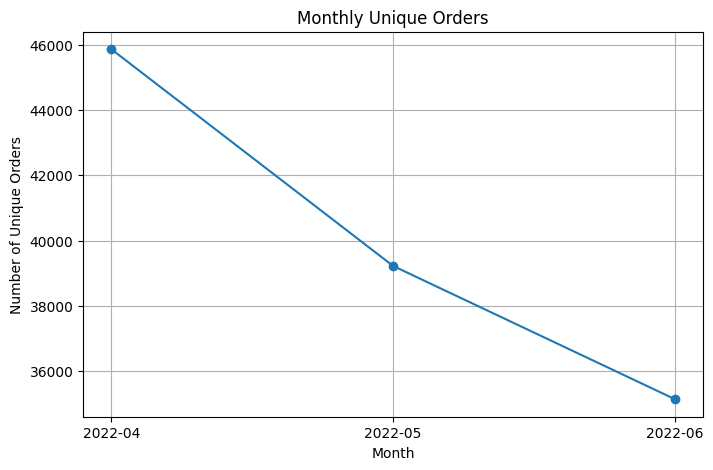

In [40]:
# Chart 1: Monthly Unique Orders

# Visualize the monthly trend in unique orders

plt.figure(figsize=(8,5))
plt.plot(
    monthly_full_months.index.astype(str),
    monthly_full_months['Unique_Orders'],
    marker = 'o'
)

plt.title('Monthly Unique Orders')
plt.xlabel('Month')
plt.ylabel('Number of Unique Orders')
plt.grid()
plt.show()

**Observation:** 
- The number of unique orders declined consistently from April to June, falling from 45,858 orders in April to 35,141 orders in June.
- This indicates a downward trend in order volume during the available full-month period.

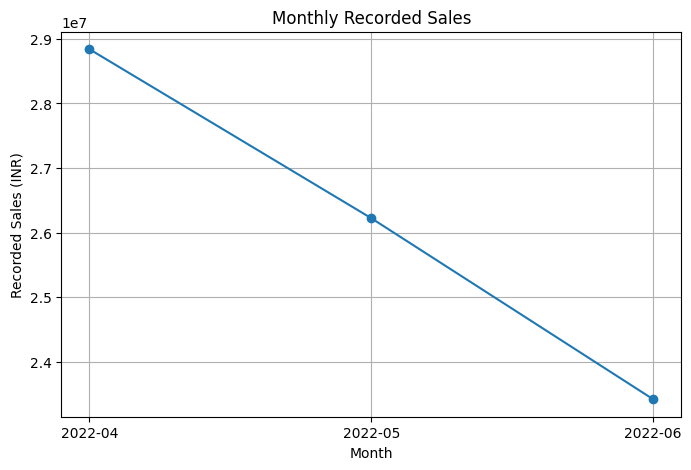

In [41]:
# Visualize the monthly trend in recorded sales value

plt.figure(figsize=(8,5))
plt.plot(
    monthly_full_months.index.astype(str),
    monthly_full_months['Recorded_Sales'],
    marker = 'o'
)

plt.title('Monthly Recorded Sales')
plt.xlabel('Month')
plt.ylabel('Recorded Sales (INR)')
plt.grid()
plt.show()

**Observation:** 
- Recorded sales declined consistently from April to June, decreasing from approximately ₹28.84 million in April to ₹26.23 million in May and ₹23.42 million in June.
- This decline aligns with the decrease in unique order volume during the same period.

In [42]:
# Calculate the average recorded sales value per unique order for each month

monthly_full_months['Average_Order_Value'] = (
    monthly_full_months['Recorded_Sales'] /
    monthly_full_months['Unique_Orders']
)

monthly_full_months

,Unique_Orders,Recorded_Sales,Average_Order_Value
Date,,,
2022-04,45858,28838708.32,628.869735
2022-05,39221,26225004.75,668.647019
2022-06,35141,23424646.38,666.590205


**Observation:** 
- Although unique orders declined from April to June, the average recorded sales value per unique order increased from ₹628.87 in April to approximately ₹668 in May and June.
- This suggests that the decline in recorded sales was primarily associated with lower order volume rather than a decrease in average order value.

In [43]:
# Analyze recorded sales and total quantity by product category

category_analysis = df.groupby('Category').agg(
    Recorded_Sales=('Amount', 'sum'),
    Total_Quantity=('Qty', 'sum'),
    Unique_Orders=('Order ID', 'nunique')
).sort_values('Recorded_Sales', ascending=False)

category_analysis

,Recorded_Sales,Total_Quantity,Unique_Orders
Category,,,
Set,39202022.03,45287,47845
kurta,21299013.70,45044,46561
Western Dress,11216072.69,13943,14994
Top,5347792.30,9903,10155
Ethnic Dress,791217.66,1053,1148
Blouse,458408.18,863,897
Bottom,150667.98,398,410
Saree,123933.76,152,144
Dupatta,915.00,3,2


**Observation:** 
- Set is the highest-performing category by recorded sales, generating approximately ₹39.2 million.
- Although Set and kurta have nearly identical quantities sold, Set generates substantially higher sales, suggesting a higher average sales value.
- Western Dress ranks third, while categories such as Saree and Dupatta contribute relatively little to overall sales.

In [44]:
# Calculate the average recorded sales value per unit for each product category

category_analysis['Average_Value_Per_Unit'] = (
    category_analysis['Recorded_Sales'] /
    category_analysis['Total_Quantity']
)

category_analysis.sort_values(
    'Average_Value_Per_Unit',
    ascending=False
)

,Recorded_Sales,Total_Quantity,Unique_Orders,Average_Value_Per_Unit
Category,,,,
Set,39202022.03,45287,47845,865.635216
Saree,123933.76,152,144,815.353684
Western Dress,11216072.69,13943,14994,804.423201
Ethnic Dress,791217.66,1053,1148,751.393789
Top,5347792.30,9903,10155,540.017399
Blouse,458408.18,863,897,531.179815
kurta,21299013.70,45044,46561,472.849074
Bottom,150667.98,398,410,378.562764
Dupatta,915.00,3,2,305.000000


**Observation:** 
- Set and kurta recorded nearly equal sales quantities, but Set generated substantially higher recorded sales because its average value per unit (₹865.64) was much higher than kurta (₹472.85).
- High average value alone does not guarantee high total sales, as seen with Saree, which has a high value per unit but very low sales volume.

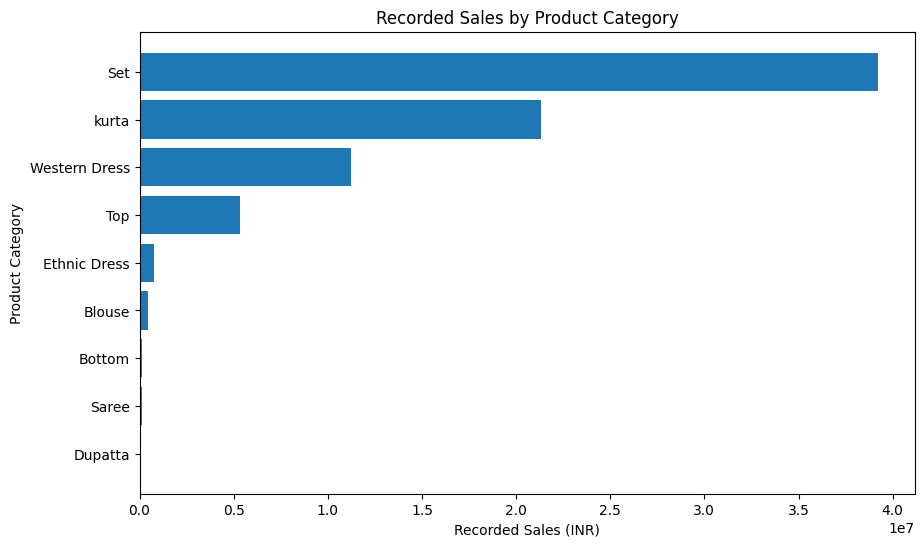

In [45]:
# Visualize recorded sales performance across product categories

category_sales = category_analysis.sort_values(
    'Recorded_Sales',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_sales.index,
    category_sales['Recorded_Sales']
)

plt.title('Recorded Sales by Product Category')
plt.xlabel('Recorded Sales (INR)')
plt.ylabel('Product Category')
plt.show()

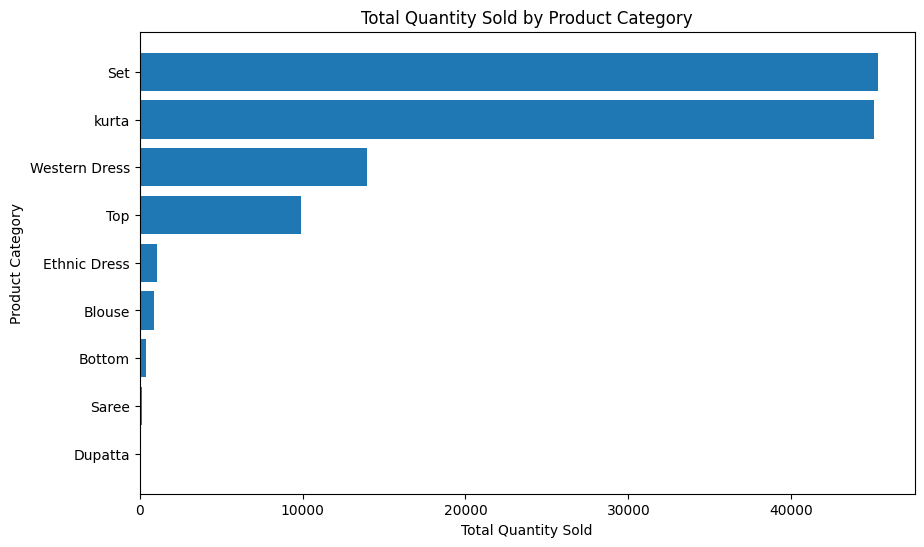

In [46]:
# Visualize total quantity sold across product categories

category_quantity = category_analysis.sort_values(
    'Total_Quantity',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    category_quantity.index,
    category_quantity['Total_Quantity']
)

plt.title('Total Quantity Sold by Product Category')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Category')
plt.show()

**Observation:** 
- Set and kurta have nearly equal sales quantities, making them the two highest-volume product categories.
- However, Set generates significantly higher recorded sales than kurta, indicating that Set has a higher average selling value per unit.
- Western Dress ranks third in both quantity and recorded sales.

In [47]:
# Analyze top product styles based on recorded sales, quantity, and unique orders

style_analysis = df.groupby('Style').agg(
    Recorded_Sales=('Amount', 'sum'),
    Total_Quantity=('Qty', 'sum'),
    Unique_Orders=('Order ID', 'nunique')
).sort_values('Recorded_Sales', ascending=False)

style_analysis.head(10)

,Recorded_Sales,Total_Quantity,Unique_Orders
Style,,,
JNE3797,2933482.00,3692,4205
J0230,1943785.48,1709,1862
SET268,1303923.56,1731,1849
J0341,1275322.87,1471,1624
J0003,981973.75,1390,1612
JNE3405,846822.36,2067,2258
J0008,819169.96,762,826
SET345,723402.79,1134,1248
SET324,720096.82,1152,1281


**Observation:** 
- JNE3797 is the highest-performing product style by a significant margin, generating ₹29.33 lakh in recorded sales.
- Sales performance does not always directly follow quantity: for example, JNE3405 recorded high sales volume but lower recorded sales compared with several other styles, while SET278 generated relatively high sales from a smaller quantity, indicating differences in product value per unit.

In [48]:
# Identify the top product styles based on total quantity sold

style_analysis.sort_values(
    'Total_Quantity',
    ascending=False
).head(10)

,Recorded_Sales,Total_Quantity,Unique_Orders
Style,,,
JNE3797,2933482.00,3692,4205
JNE3405,846822.36,2067,2258
SET268,1303923.56,1731,1849
J0230,1943785.48,1709,1862
J0341,1275322.87,1471,1624
J0003,981973.75,1390,1612
SET324,720096.82,1152,1281
SET345,723402.79,1134,1248
JNE3373,403863.95,1070,1170


**Observation:** 
- JNE3797 is the strongest overall product style, ranking first in both recorded sales and total quantity.
- JNE3405 has high sales volume but comparatively lower recorded sales, while J0230 generates high recorded sales with fewer units than JNE3405.
- This shows that product performance depends not only on quantity sold but also on the value generated per unit.

In [49]:
# Calculate the average recorded value per unit for each product style

style_analysis['Average_Value_Per_Unit'] = (
    style_analysis['Recorded_Sales'] / style_analysis['Total_Quantity']
)

style_analysis.sort_values(
    'Average_Value_Per_Unit',
    ascending=False
).head(10)

,Recorded_Sales,Total_Quantity,Unique_Orders,Average_Value_Per_Unit
Style,,,,
SAR166,770.48,0,1,inf
SET235,498.10,0,1,inf
J0238,32402.64,14,16,2314.474286
J0079,13512.64,7,9,1930.377143
J0011,166468.98,99,118,1681.504848
J0228,80249.00,48,52,1671.854167
J0239,137099.63,84,110,1632.138452
J0226,19514.39,12,13,1626.199167
J0014,98176.11,63,74,1558.350952


In [50]:
# Filter styles with a positive quantity before analyzing average value per unit

style_value_analysis = style_analysis[
    style_analysis['Total_Quantity'] > 0
].sort_values('Average_Value_Per_Unit', ascending=False)

style_value_analysis.head(10)

,Recorded_Sales,Total_Quantity,Unique_Orders,Average_Value_Per_Unit
Style,,,,
J0238,32402.64,14,16,2314.474286
J0079,13512.64,7,9,1930.377143
J0011,166468.98,99,118,1681.504848
J0228,80249.00,48,52,1671.854167
J0239,137099.63,84,110,1632.138452
J0226,19514.39,12,13,1626.199167
J0014,98176.11,63,74,1558.350952
J0240,35270.00,23,25,1533.478261
SET278,719791.48,485,546,1484.106144


**Observation:** 
- Some styles, such as J0238 and J0079, have very high average values per unit but extremely low sales volumes.
- Therefore, high average value alone does not indicate strong overall product performance. 
- ET278 shows a stronger balance between product value and sales volume, with an average value of approximately ₹1,484 per unit and 485 units sold.

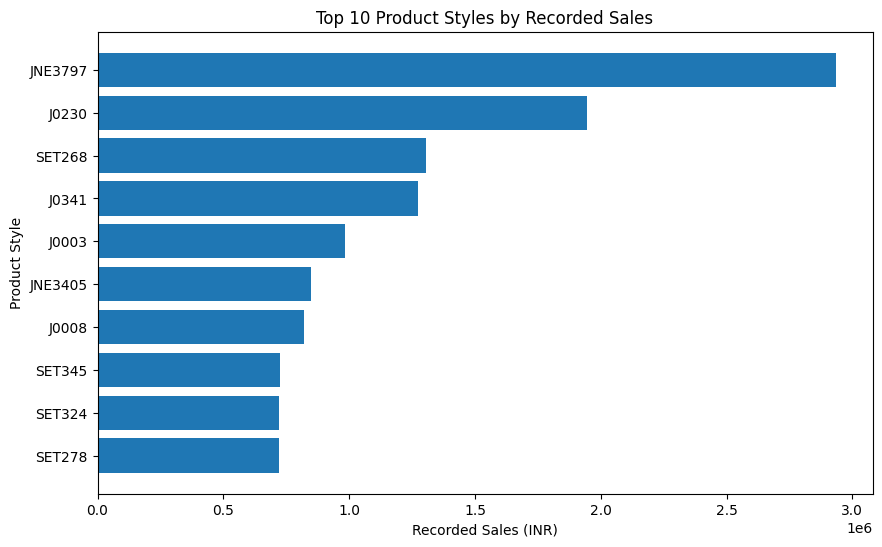

In [51]:
# Visualize the top 10 product styles based on recorded sales

top_10_styles_sales = style_analysis.head(10).sort_values(
    'Recorded_Sales',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_styles_sales.index,
    top_10_styles_sales['Recorded_Sales']
)

plt.title('Top 10 Product Styles by Recorded Sales')
plt.xlabel('Recorded Sales (INR)')
plt.ylabel('Product Style')
plt.show()

**Observation:** 
- JNE3797 is the clear leading product style by recorded sales, generating approximately ₹29.33 lakh, followed by J0230 at approximately ₹19.44 lakh.
- The remaining top styles generate considerably lower sales, showing that JNE3797 and J0230 are the strongest individual revenue-generating styles in the dataset.

In [52]:
# Analyze SKU-level performance based on recorded sales, quantity, and unique orders

sku_analysis = df.groupby('SKU').agg(
    Recorded_Sales=('Amount', 'sum'),
    Total_Quantity=('Qty', 'sum'),
    Unique_Orders=('Order ID', 'nunique')
).sort_values('Recorded_Sales', ascending=False)

sku_analysis.head(10)

,Recorded_Sales,Total_Quantity,Unique_Orders
SKU,,,
J0230-SKD-M,526536.20,467,506
JNE3797-KR-L,524581.77,661,773
J0230-SKD-S,479937.14,421,452
JNE3797-KR-M,454290.16,561,657
JNE3797-KR-S,407302.57,503,587
JNE3797-KR-XL,332155.24,415,474
J0230-SKD-L,305616.95,272,297
JNE3797-KR-XS,303616.70,386,431
SET268-KR-NP-XL,284058.96,373,386


**Observation:** 
- **J0230-SKD-M** is the highest-performing individual SKU by recorded sales at approximately ₹5.27 lakh, closely followed by JNE3797-KR-L at approximately ₹5.25 lakh.
- JNE3797 appears multiple times among the top 10 SKUs, indicating that its strong overall style performance is supported by demand across several size variants.

In [53]:
# Identify the top 10 SKUs based on total quantity sold

sku_analysis.sort_values(
    'Total_Quantity',
    ascending=False
).head(10)

,Recorded_Sales,Total_Quantity,Unique_Orders
SKU,,,
JNE3797-KR-L,524581.77,661,773
JNE3797-KR-M,454290.16,561,657
JNE3797-KR-S,407302.57,503,587
JNE3405-KR-L,194645.29,485,535
J0230-SKD-M,526536.20,467,506
J0230-SKD-S,479937.14,421,452
JNE3797-KR-XL,332155.24,415,474
JNE3405-KR-S,169808.87,399,443
JNE3797-KR-XS,303616.70,386,431


**Observation:** 
- JNE3797-KR-L is the highest-volume SKU with 661 units and also ranks among the top revenue-generating SKUs.
- J0230-SKD-M generates the highest recorded sales despite lower quantity, indicating a higher value per unit.
- Multiple JNE3797 size variants rank among the top SKUs, confirming consistently strong demand across its sizes.

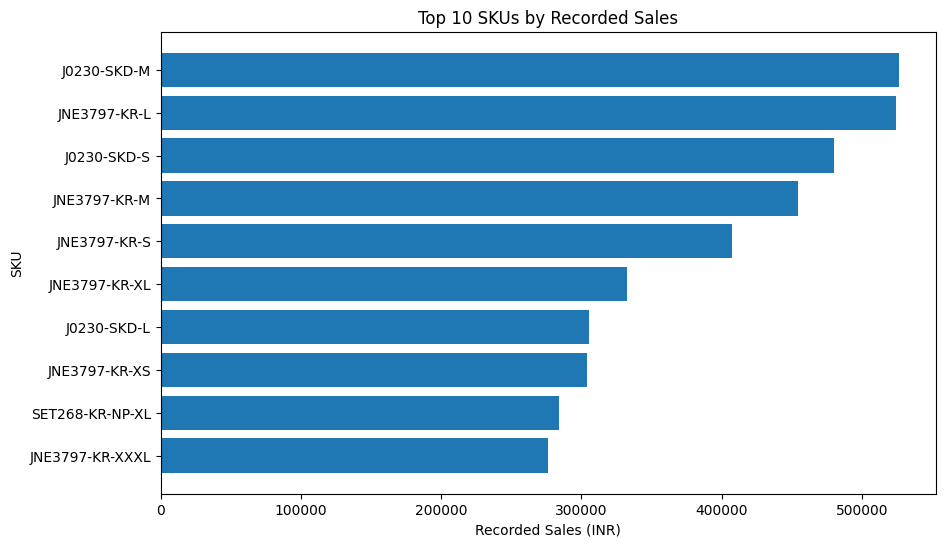

In [54]:
# Visualize the top 10 SKUs based on recorded sales

top_10_skus_sales = sku_analysis.head(10).sort_values(
    'Recorded_Sales',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_skus_sales.index,
    top_10_skus_sales['Recorded_Sales']
)

plt.title('Top 10 SKUs by Recorded Sales')
plt.xlabel('Recorded Sales (INR)')
plt.ylabel('SKU')
plt.show()

**Observation:** 
- J0230-SKD-M is the highest-performing SKU by recorded sales, closely followed by JNE3797-KR-L.
- However, JNE3797 has multiple size variants among the top 10 SKUs, showing that its overall product style generates strong sales across different sizes rather than depending on a single variant.

In [55]:
# Analyze state-level performance based on recorded sales, quantity, and unique orders

state_analysis = df.groupby('ship-state').agg(
    Recorded_Sales=('Amount', 'sum'),
    Total_Quantity=('Qty', 'sum'),
    Unique_Orders=('Order ID', 'nunique')
).sort_values('Recorded_Sales', ascending=False)

state_analysis.head(10)

,Recorded_Sales,Total_Quantity,Unique_Orders
ship-state,,,
MAHARASHTRA,13334595.14,20327,20780
KARNATAKA,10481114.37,15901,16182
TELANGANA,6916615.65,10253,10405
UTTAR PRADESH,6816109.08,9498,10062
TAMIL NADU,6515650.11,10412,10519
DELHI,4235215.97,6156,6359
KERALA,3830227.58,5813,6105
WEST BENGAL,3507880.44,5318,5653
ANDHRA PRADESH,3219831.72,4819,4979


# Observation
- Maharashtra is the largest market with ₹13.33M recorded sales and 20,327 units sold.
- Karnataka is second with ₹10.48M sales.
- Telangana, Uttar Pradesh, and Tamil Nadu are also major markets.
- The top 10 states contribute a significant portion of overall sales, showing that demand is concentrated in key regions.

In [56]:
# Analyze top 10 cities by recorded sales, quantity sold, and unique orders

top_cities = (
    df.groupby('ship-city')
      .agg(
          Recorded_Sales=('Amount', 'sum'),
          Total_Quantity=('Qty', 'sum'),
          Unique_Orders=('Order ID', 'nunique')
      )
      .sort_values('Recorded_Sales', ascending=False)
      .head(10)
)

top_cities

,Recorded_Sales,Total_Quantity,Unique_Orders
ship-city,,,
BENGALURU,6849664.99,10422,10457
HYDERABAD,4946032.82,7333,7411
MUMBAI,3704461.80,5650,5655
NEW DELHI,3613874.78,5252,5436
CHENNAI,3098745.74,4937,4925
PUNE,2337579.18,3532,3594
KOLKATA,1414978.87,2166,2249
GURUGRAM,1221618.74,1734,1771
THANE,1004355.29,1539,1613


**Observation:** 
- Bengaluru is the strongest city-level market, generating approximately ₹68.50 lakh in recorded sales, followed by Hyderabad at approximately ₹49.46 lakh.
- Mumbai, New Delhi, and Chennai also contribute strongly, indicating that major metropolitan areas are key demand centers.

In [57]:
# Compare fulfilment methods based on recorded sales, quantity, and unique orders


fulfilment_analysis = df.groupby('Fulfilment').agg(
    Recorded_Sales=('Amount', 'sum'),
    Total_Quantity=('Qty', 'sum'),
    Unique_Orders=('Order ID', 'nunique')
).sort_values('Recorded_Sales', ascending=False)

fulfilment_analysis

,Recorded_Sales,Total_Quantity,Unique_Orders
Fulfilment,,,
Amazon,54319516.0,84084,84002
Merchant,24270527.3,32562,36376


**Observation:** 
- Amazon fulfilment is the dominant fulfilment method, generating approximately ₹543.20 lakh in recorded sales compared with ₹242.71 lakh for Merchant fulfilment.
- Amazon also records substantially higher quantity and order volume, indicating that it handles the majority of sales activity in the dataset.

In [58]:
# Analyze order status distribution across Amazon and Merchant fulfilment methods

fulfilment_status = pd.crosstab(
    df['Fulfilment'],
    df['Status']
)

fulfilment_status

Status,Cancelled,Pending,Pending - Waiting for Pick Up,Shipped,Shipped - Damaged,Shipped - Delivered to Buyer,Shipped - Lost in Transit,Shipped - Out for Delivery,Shipped - Picked Up,Shipped - Rejected by Buyer,Shipped - Returned to Seller,Shipped - Returning to Seller,Shipping
Fulfilment,,,,,,,,,,,,,
Amazon,11468,415,0,77801,0,0,0,0,0,0,0,0,8
Merchant,6861,243,281,0,1,28769,5,35,973,11,1953,145,0


**Observation:** 
- Order status patterns differ significantly between fulfilment methods.
- Amazon records the majority of its completed orders under the general `Shipped` status, while Merchant orders contain more detailed delivery lifecycle statuses such as `Shipped - Delivered to Buyer`, `Returned to Seller`, and `Picked Up`.
- Therefore, fulfilment performance should be interpreted carefully because the status reporting structure is different between Amazon and Merchant.

In [59]:
# Compare B2B and B2C transactions based on recorded sales, quantity, and unique orders


b2b_analysis = df.groupby('B2B').agg(
    Recorded_Sales=('Amount', 'sum'),
    Total_Quantity=('Qty', 'sum'),
    Unique_Orders=('Order ID', 'nunique')
).sort_values('Recorded_Sales', ascending=False)

b2b_analysis

,Recorded_Sales,Total_Quantity,Unique_Orders
B2B,,,
False,77998822.51,115806,119584
True,591220.79,840,794


**Observation:** 
- B2C transactions dominate the business, contributing approximately ₹779.99 lakh in recorded sales (about 99.25% of total recorded sales), while B2B transactions contribute only about ₹5.91 lakh (approximately 0.75%).
- This indicates that the business activity in this dataset is overwhelmingly driven by B2C customers.

# Export Dataset

In [60]:
# Export the final cleaned dataset for SQL analysis

df.to_csv('amazon_sales_cleaned.csv', index=False, na_rep='')

In [61]:
# Verify the dataset record count before exporting to MySQL

print("Total records:", len(df))
print("Missing Amount:", df['Amount'].isna().sum())

Total records: 128969
Missing Amount: 7792


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128969 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Order ID            128969 non-null  object        
 1   Date                128969 non-null  datetime64[ns]
 2   Status              128969 non-null  object        
 3   Fulfilment          128969 non-null  object        
 4   Sales Channel       128969 non-null  object        
 5   ship-service-level  128969 non-null  object        
 6   Style               128969 non-null  object        
 7   SKU                 128969 non-null  object        
 8   Category            128969 non-null  object        
 9   Size                128969 non-null  object        
 10  ASIN                128969 non-null  object        
 11  Courier Status      122097 non-null  object        
 12  Qty                 128969 non-null  int64         
 13  currency            121177 non-nul